### Processing DNA Methylation Data Using SeSAMe

This document describes the steps implemented in the R script to process DNA methylation data by extracting Beta values from IDAT files using the SeSAMe package.

#### Steps Overview

- **Step 1: Install & Load Necessary Packages**
  - Check for and install `BiocManager` if missing.
  - Install required packages: `sesame`, `BiocParallel`, and `dplyr`.

- **Step 2: Load Libraries**
  - Load the `sesame`, `dplyr`, and `BiocParallel` packages.

- **Step 3: Configure Parallel Processing**
  - Register a parallel backend with 7 CPU cores.

- **Step 4: Define File Paths & Create Directories**
  - Specify the path to the raw IDAT files.
  - Create a results directory if it does not already exist.

- **Step 5: Load and Preprocess IDAT Files**
  - Use SeSAMe’s `openSesame` function to read IDAT files and extract Beta values.

- **Step 6: Save the Extracted Beta Values**
  - Save the Beta values as both CSV and RDS files for further analysis.

#### R Code

```r
########################################
### 1. Install & Load Necessary Packages
########################################
if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

# Install required packages if not already installed
BiocManager::install(c("sesame", "BiocParallel", "dplyr"))

# Load libraries
library(sesame)        # Methylation processing (SeSAMe)
library(dplyr)         # Data manipulation
library(BiocParallel)  # Parallel processing

# Parallel backend with 7 CPU cores
register(MulticoreParam(7))

#################################################
### 2. Define Paths & Ensure Results Directories
#################################################
idatPath_cases <- "/Users/nijat/Downloads/Glioma_CNV_Data_2025/methylation/idat_file"

# Create directory for results if it doesn't exist
results_folder <- "/Users/nijat/Downloads/sesame_results"
if (!dir.exists(results_folder)) {
  dir.create(results_folder, recursive = TRUE)
}

######################################################
### 3. Read & Preprocess IDAT Files Using SeSAMe ###
######################################################
cat("\n📂 Loading IDAT files using SeSAMe...\n")

# Extract Beta values from IDAT files
beta_values_cases <- openSesame(
  idatPath_cases,
  prep = "QCDPB",
  BPPARAM = MulticoreParam(7)
)

cat("\n✅ IDAT files successfully loaded with Beta values.\n")

######################################################
### 4. Save Beta Values as CSV and RDS Files ###
######################################################
write.csv(beta_values_cases, file.path(results_folder, "beta_values_cases.csv"), row.names = TRUE)
saveRDS(beta_values_cases, file.path(results_folder, "beta_values_cases.rds"))

cat("\n✅ Beta values saved as CSV and RDS.\n")


### Testing Probes Selected Previously: Data Processing & Model Training Pipeline

#### Overview
- **Import Libraries**: Load pandas, pickle, scikit-learn modules, and XGBoost.
- **Define File Paths & Constants**: Set input file locations and output paths.
- **Helper Functions**:
  - Load beta values from CSV.
  - Merge matrix data with TCGA Excel file.
  - Merge connect file with additional labels.
  - Process beta values (transpose and clean sample names).
  - Merge beta data with connect labels.
  - Clean merged data (remove missing labels and duplicates).
  - Save DataFrame as pickle.
  - Extract specified probe features.
  - Filter samples to allowed cancer types.
  - Encode labels and split data for training.
  - Train an XGBoost classifier and evaluate model performance.
- **Main Pipeline**:
  - Execute the defined steps sequentially to load, merge, clean, and process data.
  - Save intermediate and final datasets.
  - Train and evaluate a classification model.


Original beta values shape: (486427, 689)
Transposed beta values shape: (689, 486428)
Connect file merged and saved as: /Users/nijat/Downloads/connect_with_labels.csv
Merged beta and connect shape: (1345, 486431)
Saved pickle file to: /Users/nijat/Downloads/cleaned_merged_beta_values.pkl
After filtering cancer types, shape: (619, 486431)
Saved pickle file to: /Users/nijat/Downloads/filtered_cleaned_beta_values2.pkl

Test Accuracy: 0.9919

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        51
           1       1.00      1.00      1.00        39
           2       0.97      1.00      0.99        34

    accuracy                           0.99       124
   macro avg       0.99      0.99      0.99       124
weighted avg       0.99      0.99      0.99       124


Classification Report (original labels):
                    precision    recall  f1-score   support

      astrocytoma       1.00      0.98      0.99 

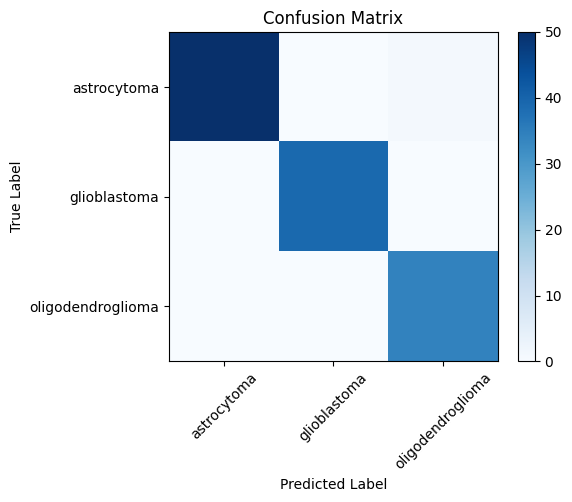

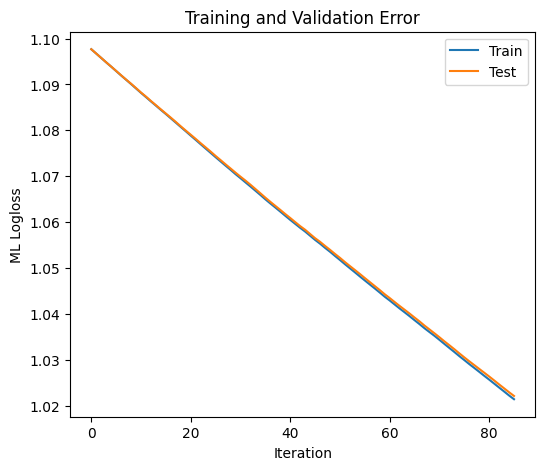

<Figure size 1000x600 with 0 Axes>

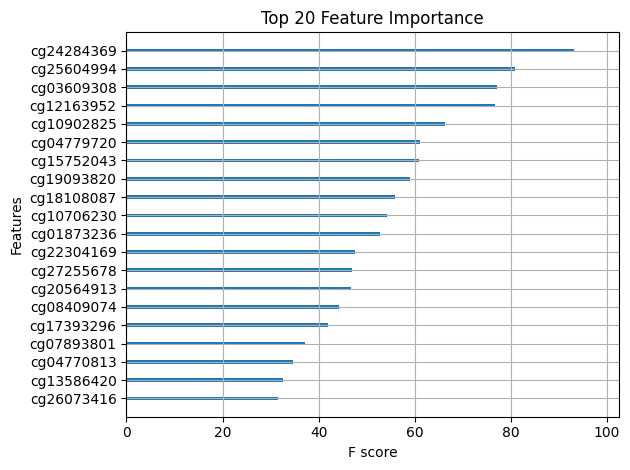

In [ ]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# File paths and constants
# ----------------------------
BETA_FILE = "/Users/nijat/Downloads/sesame_results/beta_values_cases.csv"
TCGA_EXCEL_FILE = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data/2019_TCGA-CDR-SupplementalTableS1.xlsx"
TCGA_EXCEL_SHEET = "TCGA-CDR"
MATRIX_FILE = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data/Matrix_WHO2021.csv"
CONNECT_FILE = "/Users/nijat/Desktop/connect.csv"
CONNECT_OUTPUT = "/Users/nijat/Downloads/connect_with_labels.csv"
PICKLE_CLEANED = "/Users/nijat/Downloads/cleaned_merged_beta_values.pkl"
PICKLE_FILTERED = "/Users/nijat/Downloads/filtered_cleaned_beta_values2.pkl"

# ----------------------------
# Helper Functions
# ----------------------------
def load_beta_values(file_path):
    try:
        df = pd.read_csv(file_path, index_col=0)
        print("Beta values loaded with shape:", df.shape)
        return df
    except FileNotFoundError:
        print(f"File not found: {file_path}.")
        return None

def merge_matrix_excel(matrix_path, excel_path, sheet_name):
    df_excel = pd.read_excel(excel_path, sheet_name=sheet_name)
    mx_df = pd.read_csv(matrix_path)
    df_matrix = pd.merge(
        mx_df,
        df_excel[['bcr_patient_barcode', 'OS', 'OS.time']],
        left_on='Patient_ID',
        right_on='bcr_patient_barcode',
        how='left'
    )
    return df_matrix

def merge_connect_with_labels(connect_path, df_matrix, output_path):
    df_connect = pd.read_csv(connect_path)
    df_merged = pd.merge(
        df_connect,
        df_matrix[['Patient_ID', 'classification.2021_simplified.labels', 'OS', 'OS.time']],
        left_on='Sample_Name',
        right_on='Patient_ID',
        how='left'
    )
    df_merged.drop(columns=['Patient_ID'], inplace=True)
    df_merged.to_csv(output_path, index=False)
    print("Connect file merged and saved as:", output_path)
    return df_merged

def process_beta_values(file_path):
    # Load, then transpose so that samples become rows and probes become columns
    df = pd.read_csv(file_path, index_col=0)
    print("Original beta values shape:", df.shape)
    df = df.transpose().reset_index().rename(columns={'index': 'Sample'})
    print("Transposed beta values shape:", df.shape)
    return df

def clean_samples(df, col="Sample"):
    df[col] = df[col].str.strip().str.upper()
    return df

def merge_beta_connect(beta_df, connect_df):
    merged = pd.merge(
        beta_df,
        connect_df[['Sample', 'classification.2021_simplified.labels', 'OS', 'OS.time']],
        on='Sample',
        how='left'
    )
    print("Merged beta and connect shape:", merged.shape)
    return merged

def clean_merged_df(df):
    df = df.dropna(subset=['classification.2021_simplified.labels'])
    df = df.drop_duplicates(subset=['Sample'], keep='last')
    return df

def save_pickle(df, file_path):
    df.to_pickle(file_path)
    print(f"Saved pickle file to: {file_path}")

def extract_features(df, features):
    available = [f for f in features if f in df.columns]
    if len(available) != len(features):
        missing = set(features) - set(available)
        print("Missing features:", missing)
    return df[available], df['classification.2021_simplified.labels']

def filter_cancer_types(df, allowed_labels=("glioblastoma", "astrocytoma", "oligodendroglioma")):
    df['classification.2021_simplified.labels'] = df['classification.2021_simplified.labels'].str.lower()
    df = df[df['classification.2021_simplified.labels'].isin(allowed_labels)]
    print("After filtering cancer types, shape:", df.shape)
    return df

def encode_and_split(df, feature_cols, test_size=0.2, random_state=42):
    le = LabelEncoder()
    df['labels_encoded'] = le.fit_transform(df['classification.2021_simplified.labels'])
    X = df[feature_cols]
    y = df['labels_encoded']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test, le

def train_xgb(X_train, y_train, X_test, y_test, le):
    best_params = {
        "colsample_bytree": 0.25276592895441286,
        "learning_rate": 0.001037772866579333,
        "max_depth": 5,
        "n_estimators": 86,
        "reg_alpha": 11.553140668247567,
        "reg_lambda": 14.308787386296595,
        "subsample": 0.6914397498447116,
        "objective": "multi:softmax",
        "num_class": len(y_train.unique()),
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "n_jobs": -1
    }
    model = xgb.XGBClassifier(**best_params)
    
    # Train with evaluation set to capture training history; remove eval_metric from fit call
    eval_set = [(X_train, y_train), (X_test, y_test)]
    model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
    
    # Evaluate predictions
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Decode labels for readability
    y_pred_labels = le.inverse_transform(y_pred)
    y_test_labels = le.inverse_transform(y_test)
    print("\nClassification Report (original labels):\n", classification_report(y_test_labels, y_pred_labels))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(le.classes_))
    plt.xticks(tick_marks, le.classes_, rotation=45)
    plt.yticks(tick_marks, le.classes_)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    # Plot training and validation error (ML logloss)
    evals_result = model.evals_result()
    plt.figure(figsize=(6,5))
    plt.plot(evals_result['validation_0']['mlogloss'], label="Train")
    plt.plot(evals_result['validation_1']['mlogloss'], label="Test")
    plt.xlabel("Iteration")
    plt.ylabel("ML Logloss")
    plt.title("Training and Validation Error")
    plt.legend()
    plt.show()
    
    # Plot feature importance (Top 20 features)
    plt.figure(figsize=(10,6))
    xgb.plot_importance(model, max_num_features=20, importance_type='gain', show_values=False)
    plt.title("Top 20 Feature Importance")
    plt.tight_layout()
    plt.show()

# ----------------------------
# Main pipeline
# ----------------------------
def main():
    # Load beta values and process them
    beta_df = process_beta_values(BETA_FILE)
    beta_df = clean_samples(beta_df)
    
    # Load and merge connect file with additional labels
    df_matrix = merge_matrix_excel(MATRIX_FILE, TCGA_EXCEL_FILE, TCGA_EXCEL_SHEET)
    connect_df = merge_connect_with_labels(CONNECT_FILE, df_matrix, CONNECT_OUTPUT)
    connect_df = clean_samples(connect_df)
    
    # Merge beta values with connect labels and clean up
    merged_df = merge_beta_connect(beta_df, connect_df)
    merged_df = clean_merged_df(merged_df)
    save_pickle(merged_df, PICKLE_CLEANED)
    
    # List of probe features to extract
    features = [
        'cg23609985', 'cg03609308', 'cg22304169', 'cg02483271', 'cg00339300',
        'cg20326704', 'cg26146617', 'cg27255678', 'cg04779720', 'cg10902825',
        'cg08535928', 'cg20629587', 'cg05976753', 'cg12163952', 'cg24934561',
        'cg25604994', 'cg08409074', 'cg01873236', 'cg00090619', 'cg18943693',
        'cg20564913', 'cg12869912', 'cg12621315', 'cg17213402', 'cg22230604',
        'cg13999415', 'cg15472784', 'cg02864688', 'cg12630147', 'cg10706230',
        'cg20276103', 'cg04770813', 'cg03962809', 'cg19093820', 'cg24284369',
        'cg03505995', 'cg25467973', 'cg20532370', 'cg14453978', 'cg13586420',
        'cg25503044', 'cg20732367', 'cg18108087', 'cg08090640', 'cg08414647',
        'cg17393296', 'cg07893801', 'cg14640066', 'cg25653638', 'cg21195256',
        'cg05903444', 'cg26073416', 'cg17895157', 'cg01660911', 'cg12210255',
        'cg04437966', 'cg09219721', 'cg01813033', 'cg15752043', 'cg14030586',
        'cg14905632', 'cg04951819', 'cg01547541', 'cg26694713', 'cg18875371',
        'cg19490297', 'cg24081688', 'cg02103647', 'cg24597705', 'cg07482935'
    ]
    
    # Optionally, extract features here (prints missing features if any)
    X_dummy, y_dummy = extract_features(merged_df, features)
    
    # Further clean and filter to allowed cancer types
    merged_df = clean_merged_df(merged_df) 
    merged_df = filter_cancer_types(merged_df)
    save_pickle(merged_df, PICKLE_FILTERED)
    
    # Encode labels and split data for training
    available_features = [f for f in features if f in merged_df.columns]
    X_train, X_test, y_train, y_test, le = encode_and_split(merged_df, available_features)
    
    # Train and evaluate the model (with plots)
    train_xgb(X_train, y_train, X_test, y_test, le)

if __name__ == "__main__":
    main()
